# Atobb vs TTLJ XGBoost Training and ONNX Export

This notebook trains a first-pass XGBoost classifier using the `Training_Tree` produced by `AtobbMLTree`.

- Signal: `TTToHcToWAToBB-MHc100_MA60.root` by default
- Background: `TTLJ_powheg.root` by default
- Main weight: `weight_train`
- Output model: `xgboost_atobb_ttlJ.onnx`

Before running, check that the ROOT paths below match your actual output directory.


## 1. Imports

Run this in the `MLHEP` kernel/environment where `ROOT`, `xgboost`, `onnxmltools`, and `skl2onnx` are installed.


In [1]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import ROOT
import xgboost as xgb
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix

import onnx
from onnxmltools.convert import convert_xgboost as convert_xgboost_booster
from skl2onnx.common.data_types import FloatTensorType

np.random.seed(42)


## 2. Input ROOT files

Change these paths if your files are somewhere else.


In [2]:
BASE_DIR = "/data9/Users/eunsu/SKNanoOutput/AtobbMLTree/2024"

SIG_FILES = [
    f"{BASE_DIR}/TTToHcToWAToBB-MHc100_MA60.root",
]

BKG_FILES = [
    f"{BASE_DIR}/TTLJ_powheg.root",
]

TREE_NAME = "Training_Tree"
MODEL_DIR = "/data9/Users/eunsu/MachineLearning/models"
os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_NAME = "xgboost_atobb_ttlJ"

ONNX_PATH = f"{MODEL_DIR}/{MODEL_NAME}.onnx"
FEATURE_JSON_PATH = f"{MODEL_DIR}/{MODEL_NAME}_features.json"
SCALER_JSON_PATH = f"{MODEL_DIR}/{MODEL_NAME}_scaler.json"
SCALER_PICKLE_PATH = f"{MODEL_DIR}/{MODEL_NAME}_scaler.pkl"

# Background statistics test.
# Change this to 10000, 20000, 50000, 100000, or None.
N_BKG = 20000

# Booster scan. Later, choose one value and rerun for the final model.
NUM_BOOST_ROUND = 100  # Try 20, 50, 100, 200, 300

# Preprocessing choice: "standard", "minmax", or None
SCALER_TYPE = "standard"

print("Signal files:")
for p in SIG_FILES:
    print("  ", p, os.path.exists(p))
print("Background files:")
for p in BKG_FILES:
    print("  ", p, os.path.exists(p))


Signal files:
   /data9/Users/eunsu/SKNanoOutput/AtobbMLTree/2024/TTToHcToWAToBB-MHc100_MA60.root True
Background files:
   /data9/Users/eunsu/SKNanoOutput/AtobbMLTree/2024/TTLJ_powheg.root True


## 3. Load ROOT tree into pandas

This function reads only the branches we need, which is faster and safer than reading everything.


In [3]:
def read_training_tree(files, tree_name="Training_Tree", branches=None):
    dfs = []
    for path in files:
        if not os.path.exists(path):
            raise FileNotFoundError(path)
        f = ROOT.TFile.Open(path, "READ")
        if not f or f.IsZombie():
            raise RuntimeError(f"Cannot open ROOT file: {path}")
        tree = f.Get(tree_name)
        if not tree:
            raise RuntimeError(f"Cannot find tree '{tree_name}' in {path}")
        rdf = ROOT.RDataFrame(tree)
        if branches is None:
            arr = rdf.AsNumpy()
        else:
            arr = rdf.AsNumpy(branches)
        df = pd.DataFrame(arr)
        df["source_file"] = os.path.basename(path)
        dfs.append(df)
        f.Close()
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()


## 4. Feature list

First-pass feature set. These are physics-motivated variables from `AtobbMLTree`: jet activity, b-tag topology, bb-pair masses, and ttbar reconstruction variables.

Do **not** include `label`, `weight_*`, or `source_file` as ML inputs.


In [4]:
FEATURES = [
    # event-level activity
    "HT", "ST", "MET_Pt",

    # multiplicity / topology
    "nJets", "nBJets",

    # A -> bb candidates from first three b-tagged jets
    "bb_mass_01", "bb_mass_02", "bb_mass_12",
    "bb_dr_01", "bb_dr_02", "bb_dr_12",

    # lepton and MET
    "Muon0_Pt", "Muon0_Eta", "MET_Phi",
]

WEIGHT_COL = "weight_train"
LABEL_COL = "label"
BRANCHES_TO_READ = sorted(set(FEATURES + [WEIGHT_COL, "weight_nominal", LABEL_COL]))

print(f"Number of features = {len(FEATURES)}")
print(FEATURES)


Number of features = 14
['HT', 'ST', 'MET_Pt', 'nJets', 'nBJets', 'bb_mass_01', 'bb_mass_02', 'bb_mass_12', 'bb_dr_01', 'bb_dr_02', 'bb_dr_12', 'Muon0_Pt', 'Muon0_Eta', 'MET_Phi']


## 5. Read signal and background samples

For this notebook, we override the label explicitly to avoid relying on sample-name parsing.


In [5]:
df_sig = read_training_tree(SIG_FILES, TREE_NAME, branches=BRANCHES_TO_READ)
df_bkg = read_training_tree(BKG_FILES, TREE_NAME, branches=BRANCHES_TO_READ)

df_sig[LABEL_COL] = 1
df_bkg[LABEL_COL] = 0

print("Before background limit:")
print("  signal entries:", len(df_sig))
print("  bkg entries   :", len(df_bkg))

if N_BKG is not None and len(df_bkg) > N_BKG:
    df_bkg = df_bkg.sample(n=N_BKG, random_state=42).reset_index(drop=True)

print("After background limit:")
print("  signal entries:", len(df_sig))
print("  bkg entries   :", len(df_bkg))

df_sig.head()


Before background limit:
  signal entries: 2512
  bkg entries   : 740083
After background limit:
  signal entries: 2512
  bkg entries   : 20000


,HT,MET_Phi,MET_Pt,Muon0_Eta,Muon0_Pt,ST,bb_dr_01,bb_dr_02,bb_dr_12,bb_mass_01,bb_mass_02,bb_mass_12,label,nBJets,nJets,weight_nominal,weight_train,source_file
0,301.794464,2.545410,79.100998,0.452484,33.292381,414.187836,2.837198,0.475017,2.481278,87.923615,20.605341,81.184845,1,4,7,0.002500,0.002677,TTToHcToWAToBB-MHc100_MA60.root
1,1099.348267,3.060547,259.426666,0.586639,36.566620,1395.341553,1.857704,3.082518,2.311926,492.070190,669.027466,495.764587,1,4,7,0.003973,0.004254,TTToHcToWAToBB-MHc100_MA60.root
2,242.727707,-3.095703,129.311447,-1.704147,32.820026,404.859192,0.751331,2.590753,1.848499,44.584942,90.598656,66.793411,1,5,6,0.005552,0.005337,TTToHcToWAToBB-MHc100_MA60.root
3,1209.330322,2.704102,57.047997,-0.182398,32.327713,1298.706055,0.570610,2.081767,2.572813,127.544373,291.150177,338.230621,1,5,8,0.003688,0.004044,TTToHcToWAToBB-MHc100_MA60.root
4,684.477966,-1.931885,55.614685,0.362274,30.218946,770.311584,2.622389,2.946206,0.893620,417.881104,283.634247,103.473869,1,4,6,0.009508,0.010181,TTToHcToWAToBB-MHc100_MA60.root


## 6. Basic cleaning and weight handling

- Replace `inf` with `NaN`
- Drop rows with invalid feature/weight values
- Use `abs(weight_train)` by default for training stability
- Normalize total signal/background weights to similar scale

If you want signed MC weights later, keep them for final histograms, but for first classifier training this is safer.


In [6]:
def print_bad_values(df, features, name):
    print(f"[{name}] bad value check")
    for feat in features:
        n_nan = df[feat].isna().sum()
        n_inf = np.isinf(df[feat]).sum()
        n_sentinel = (df[feat] <= -998).sum()
        if n_nan or n_inf or n_sentinel:
            print(f"  {feat:15s} NaN={n_nan:6d}, Inf={n_inf:6d}, <=-998={n_sentinel:6d}")

print_bad_values(df_sig, FEATURES, "signal raw")
print_bad_values(df_bkg, FEATURES, "bkg raw")


[signal raw] bad value check
[bkg raw] bad value check


In [19]:
def clean_df(df, features, weight_col, remove_sentinel=True):
    use_cols = features + [LABEL_COL, weight_col]
    out = df[use_cols].copy()
    out = out.replace([np.inf, -np.inf], np.nan)

    # Optionally replace sentinel values (e.g. -999) with NaN to be dropped later.
    if remove_sentinel:
        for feat in features:
            out.loc[out[feat] <= -998, feat] = np.nan

    out = out.dropna(subset=use_cols)
    out[weight_col] = out[weight_col].astype(float)

    # Remove zero or negative weights, as they can cause issues for training.
    out = out[out[weight_col] > 0].copy()
    return out

df_sig_clean = clean_df(df_sig, FEATURES, WEIGHT_COL)
df_bkg_clean = clean_df(df_bkg, FEATURES, WEIGHT_COL)

# Use absolute training weights for first-pass ML stability.
df_sig_clean["ml_weight"] = np.abs(df_sig_clean[WEIGHT_COL].to_numpy(dtype=float))
df_bkg_clean["ml_weight"] = np.abs(df_bkg_clean[WEIGHT_COL].to_numpy(dtype=float))

# Normalize total class weights to avoid one class dominating the loss.
sig_sumw = df_sig_clean["ml_weight"].sum()
bkg_sumw = df_bkg_clean["ml_weight"].sum()

if sig_sumw <= 0 or bkg_sumw <= 0:
    print("WARNING: weight sum is non-positive. Falling back to unit weights.")
    df_sig_clean["ml_weight"] = 1.0
    df_bkg_clean["ml_weight"] = 1.0
    sig_sumw = len(df_sig_clean)
    bkg_sumw = len(df_bkg_clean)

# Make each class have approximately the same total training weight.
df_sig_clean["ml_weight"] = np.abs(df_sig_clean[WEIGHT_COL])
df_bkg_clean["ml_weight"] = np.abs(df_bkg_clean[WEIGHT_COL])

scale_sig = len(df_bkg_clean) / len(df_sig_clean)
df_sig_clean["ml_weight"] *= scale_sig

print("After cleaning:")
print("  signal entries:", len(df_sig_clean), "sum ml weight:", df_sig_clean["ml_weight"].sum())
print("  bkg entries   :", len(df_bkg_clean), "sum ml weight:", df_bkg_clean["ml_weight"].sum())
print("Raw weight summary:")
print("signal weight_train")
print(df_sig_clean[WEIGHT_COL].describe())
print("background weight_train")
print(df_bkg_clean[WEIGHT_COL].describe())

After cleaning:
  signal entries: 2512 sum ml weight: 94.73880669697496
  bkg entries   : 19930 sum ml weight: 1789.2114907428622
Raw weight summary:
signal weight_train
count    2512.000000
mean        0.004754
std         0.002893
min         0.001120
25%         0.003185
50%         0.003949
75%         0.005758
max         0.025334
Name: weight_train, dtype: float64
background weight_train
count    19930.000000
mean         0.089775
std          0.055106
min          0.020530
25%          0.060351
50%          0.073182
75%          0.108859
max          0.547373
Name: weight_train, dtype: float64


## 7. Quick sanity plots

These are not for final presentation, just to confirm signal/background shape differences.


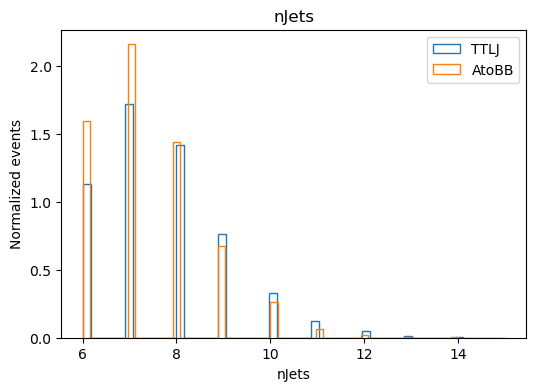

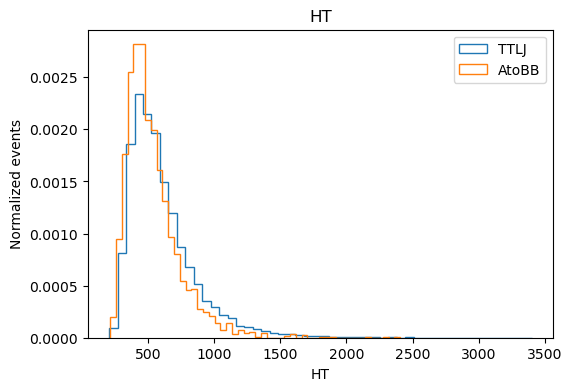

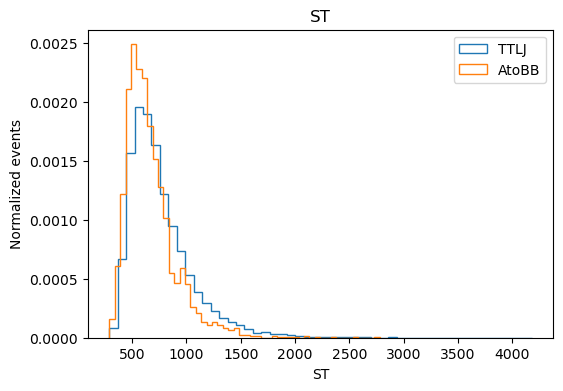

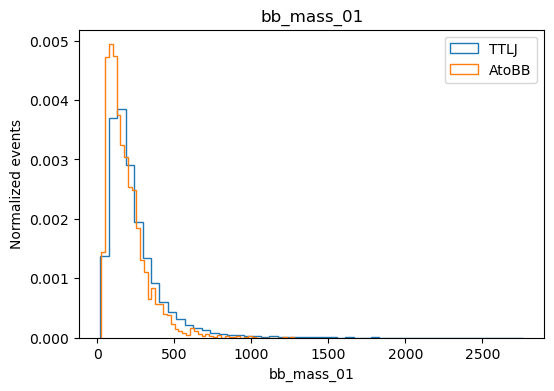

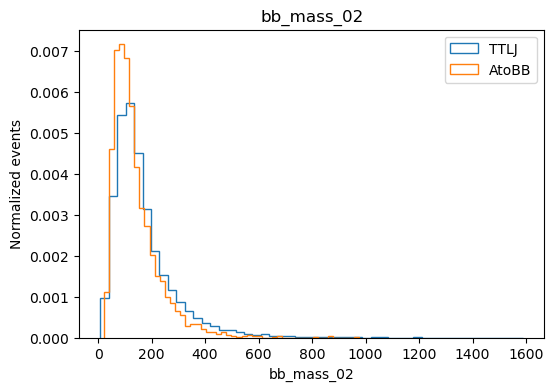

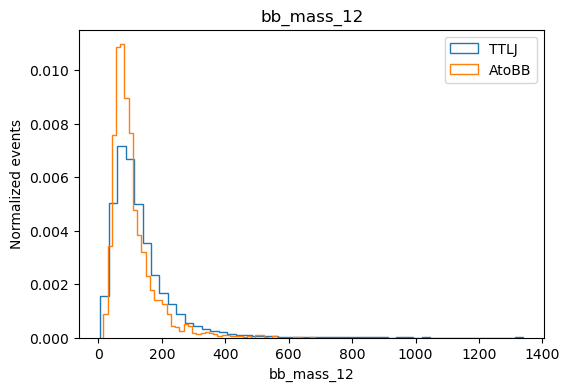

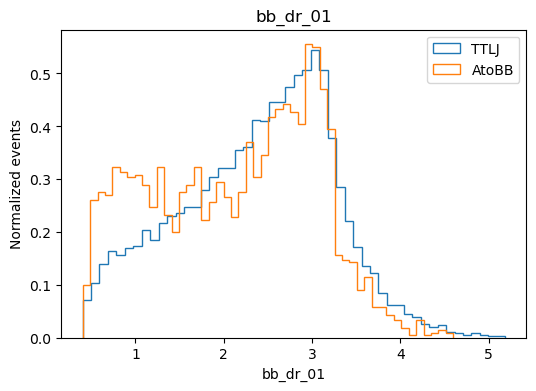

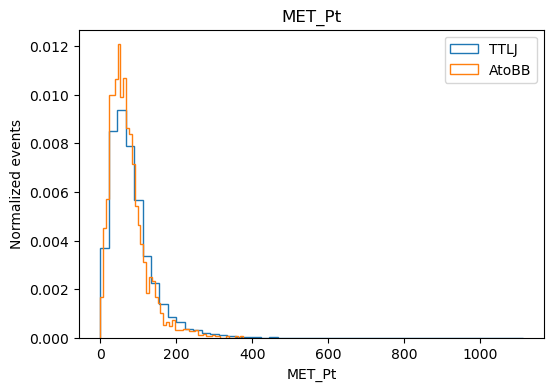

In [20]:
def plot_feature(sig, bkg, feature, bins=50, x_range=None, logy=False):
    plt.figure(figsize=(6, 4))
    plt.hist(bkg[feature], bins=bins, range=x_range, histtype="step", density=True, label="TTLJ")
    plt.hist(sig[feature], bins=bins, range=x_range, histtype="step", density=True, label="AtoBB")
    if logy:
        plt.yscale("log")
    plt.xlabel(feature)
    plt.ylabel("Normalized events")
    plt.title(feature)
    plt.legend()
    plt.show()

for feat in ["nJets", "HT", "ST", "bb_mass_01", "bb_mass_02", "bb_mass_12", "bb_dr_01", "MET_Pt"]:
    plot_feature(df_sig_clean, df_bkg_clean, feat, bins=50)

## 8. Train / validation split

Use stratified split so both train and validation contain signal and background.


In [21]:
df_all = pd.concat([df_sig_clean, df_bkg_clean], ignore_index=True)

train_df, val_df = train_test_split(
    df_all,
    test_size=0.2,
    random_state=42,
    stratify=df_all[LABEL_COL],
)

X_train = train_df[FEATURES].copy()
y_train = train_df[LABEL_COL].astype(int).copy()
w_train = train_df["ml_weight"].astype(float).copy()
# w_train = np.ones(len(train_df))

X_val = val_df[FEATURES].copy()
y_val = val_df[LABEL_COL].astype(int).copy()
w_val = val_df["ml_weight"].astype(float).copy()
# w_val = np.ones(len(val_df))

used_columns = list(X_train.columns)

if SCALER_TYPE == "standard":
    scaler = StandardScaler()
elif SCALER_TYPE == "minmax":
    scaler = MinMaxScaler()
elif SCALER_TYPE is None:
    scaler = None
else:
    raise ValueError(f"Unknown SCALER_TYPE = {SCALER_TYPE}")

if scaler is not None:
    X_train_np = scaler.fit_transform(X_train)
    X_val_np = scaler.transform(X_val)
else:
    X_train_np = X_train.to_numpy(dtype=np.float32)
    X_val_np = X_val.to_numpy(dtype=np.float32)

X_train = pd.DataFrame(X_train_np, columns=used_columns)
X_val = pd.DataFrame(X_val_np, columns=used_columns)

# ONNX/XGBoost conversion is safer with integer feature names.
X_train.columns = range(len(used_columns))
X_val.columns = range(len(used_columns))

print("Train label counts:")
print(y_train.value_counts())
print("Validation label counts:")
print(y_val.value_counts())
print("used columns:")
for i, c in enumerate(used_columns):
    print(f"  {i:02d}: {c}")




Train label counts:
label
0    15943
1     2010
Name: count, dtype: int64
Validation label counts:
label
0    3987
1     502
Name: count, dtype: int64
used columns:
  00: HT
  01: ST
  02: MET_Pt
  03: nJets
  04: nBJets
  05: bb_mass_01
  06: bb_mass_02
  07: bb_mass_12
  08: bb_dr_01
  09: bb_dr_02
  10: bb_dr_12
  11: Muon0_Pt
  12: Muon0_Eta
  13: MET_Phi


## 9. Train XGBoost model

This is a first-pass model. Tune `max_depth`, `eta`, and `num_boost_round` later.


In [22]:
dtrain = xgb.DMatrix(X_train, label=y_train, weight=w_train)
dval = xgb.DMatrix(X_val, label=y_val, weight=w_val)

params = {
    "max_depth": 4,
    "eta": 0.05,
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    # "min_child_weight": 10,
    # "lambda": 1.0,
    # "alpha": 0.5,
    "random_state": 42,
    "tree_method": "hist",
    # "scale_pos_weight": len(df_bkg_clean) / len(df_sig_clean)
}

evals_result = {}
model = xgb.train(
    params,
    dtrain,
    num_boost_round=NUM_BOOST_ROUND,
    evals=[(dtrain, "train"), (dval, "validation")],
    # early_stopping_rounds=20,
    evals_result=evals_result,
    verbose_eval=max(1, NUM_BOOST_ROUND // 10),
)

print("Finished training with num_boost_round =", NUM_BOOST_ROUND)
print("Final train logloss     =", evals_result["train"]["logloss"][-1])
print("Final validation logloss=", evals_result["validation"]["logloss"][-1])

[0]	train-logloss:0.19702	validation-logloss:0.20324
[10]	train-logloss:0.18364	validation-logloss:0.19131
[20]	train-logloss:0.17714	validation-logloss:0.18548
[30]	train-logloss:0.17311	validation-logloss:0.18224
[40]	train-logloss:0.17026	validation-logloss:0.17988
[50]	train-logloss:0.16822	validation-logloss:0.17850
[60]	train-logloss:0.16638	validation-logloss:0.17735
[70]	train-logloss:0.16519	validation-logloss:0.17657
[80]	train-logloss:0.16415	validation-logloss:0.17575
[90]	train-logloss:0.16331	validation-logloss:0.17522
[99]	train-logloss:0.16252	validation-logloss:0.17477
Finished training with num_boost_round = 100
Final train logloss     = 0.1625156232514362
Final validation logloss= 0.17476945918619538


In [23]:
RUN_SCAN = False

if RUN_SCAN:
    scan_bkg_entries = [10000, 20000, 50000, 100000]
    scan_rounds = [20, 50, 100, 200, 300]
    scan_results = []

    for n_bkg in scan_bkg_entries:
        temp_bkg = df_bkg_clean.sample(n=min(n_bkg, len(df_bkg_clean)), random_state=42).copy()
        temp_all = pd.concat([df_sig_clean, temp_bkg], ignore_index=True)
        tr, va = train_test_split(temp_all, test_size=0.2, random_state=42, stratify=temp_all[LABEL_COL])

        Xtr_raw = tr[FEATURES].astype(float)
        Xva_raw = va[FEATURES].astype(float)
        ytr = tr[LABEL_COL].astype(int)
        yva = va[LABEL_COL].astype(int)
        wtr = tr["ml_weight"].astype(float)
        wva = va["ml_weight"].astype(float)

        scan_scaler = StandardScaler()
        Xtr = pd.DataFrame(scan_scaler.fit_transform(Xtr_raw), columns=range(len(FEATURES)))
        Xva = pd.DataFrame(scan_scaler.transform(Xva_raw), columns=range(len(FEATURES)))

        dtr = xgb.DMatrix(Xtr, label=ytr, weight=wtr)
        dva = xgb.DMatrix(Xva, label=yva, weight=wva)

        for n_round in scan_rounds:
            m = xgb.train(params, dtr, num_boost_round=n_round, evals=[(dva, "val")], verbose_eval=False)
            pred = m.predict(dva)
            fpr, tpr, _ = roc_curve(yva, pred, sample_weight=wva)
            auc_val = auc(fpr, tpr)
            scan_results.append({"n_bkg": n_bkg, "num_boost_round": n_round, "auc": auc_val})

    scan_df = pd.DataFrame(scan_results)
    display(scan_df)

## 10. Evaluation: ROC and score distributions


AUC = 0.7781640873498035


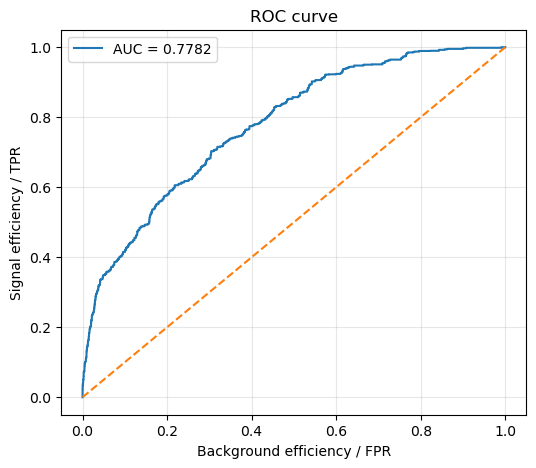

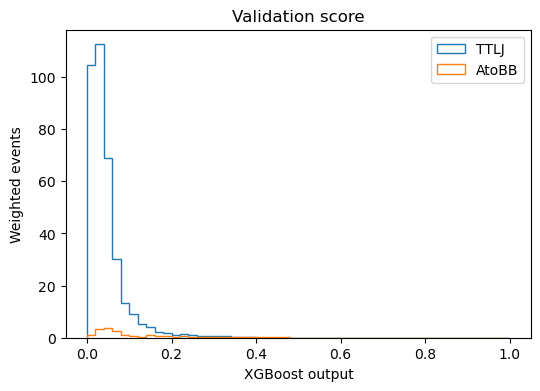

In [24]:
y_pred = model.predict(dval)
fpr, tpr, thresholds = roc_curve(y_val, y_pred, sample_weight=w_val)
auc_val = auc(fpr, tpr)
print("AUC =", auc_val)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_val:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Background efficiency / FPR")
plt.ylabel("Signal efficiency / TPR")
plt.title("ROC curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6,4))
plt.hist(y_pred[y_val.to_numpy() == 0], bins=50, range=(0,1), histtype="step", weights=w_val[y_val == 0], label="TTLJ")
plt.hist(y_pred[y_val.to_numpy() == 1], bins=50, range=(0,1), histtype="step", weights=w_val[y_val == 1], label="AtoBB")
plt.xlabel("XGBoost output")
plt.ylabel("Weighted events")
plt.legend()
plt.title("Validation score")
plt.show()


## 11. Overtraining check

Compare train vs validation score shapes.


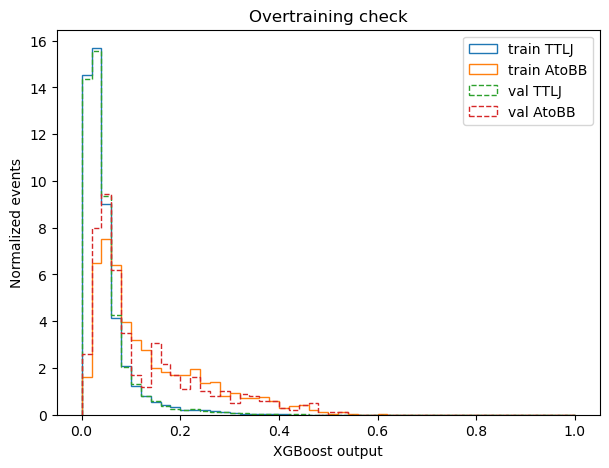

In [25]:
pred_train = model.predict(dtrain)
pred_val = model.predict(dval)

y_train_np = y_train.to_numpy()
y_val_np = y_val.to_numpy()
w_train_np = w_train.to_numpy()
w_val_np = w_val.to_numpy()

plt.figure(figsize=(7, 5))
plt.hist(pred_train[y_train_np == 0], bins=50, range=(0, 1), histtype="step", density=True, label="train TTLJ")
plt.hist(pred_train[y_train_np == 1], bins=50, range=(0, 1), histtype="step", density=True, label="train AtoBB")
plt.hist(pred_val[y_val_np == 0], bins=50, range=(0, 1), histtype="step", density=True, linestyle="--", label="val TTLJ")
plt.hist(pred_val[y_val_np == 1], bins=50, range=(0, 1), histtype="step", density=True, linestyle="--", label="val AtoBB")
plt.xlabel("XGBoost output")
plt.ylabel("Normalized events")
plt.title("Overtraining check")
plt.legend()
plt.show()


## 12. Feature importance


       feature      gain
0       nBJets  4.286009
1   bb_mass_01  0.976267
2   bb_mass_12  0.950068
3     bb_dr_02  0.679269
4           ST  0.626839
5     bb_dr_12  0.614035
6        nJets  0.574508
7   bb_mass_02  0.555611
8     bb_dr_01  0.544367
9     Muon0_Pt  0.510046
10      MET_Pt  0.440092
11   Muon0_Eta  0.312641
12          HT  0.256800
13     MET_Phi  0.255414


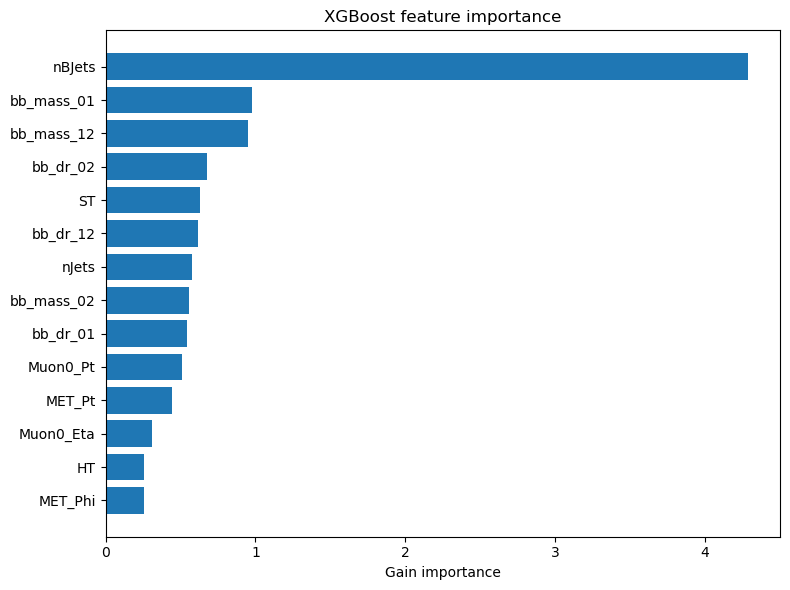

In [26]:
importance = model.get_score(importance_type="gain")
importance_named = []
for key, val in importance.items():
    # key is like f0, f1, ...
    idx = int(key[1:]) if key.startswith("f") else int(key)
    importance_named.append((used_columns[idx], val))
importance_named = sorted(importance_named, key=lambda x: x[1], reverse=True)

imp_df = pd.DataFrame(importance_named, columns=["feature", "gain"])
print(imp_df.head(30))

plt.figure(figsize=(8,6))
plot_df = imp_df.head(20).iloc[::-1]
plt.barh(plot_df["feature"], plot_df["gain"])
plt.xlabel("Gain importance")
plt.title("XGBoost feature importance")
plt.tight_layout()
plt.show()


## 13. Export to ONNX

This creates `xgboost_atobb_ttlJ.onnx` and a JSON file containing the exact feature order.

The C++ inference input vector **must use this exact order**.


In [ ]:
initial_type = [("input", FloatTensorType([None, len(used_columns)]))]
onnx_model = convert_xgboost_booster(model, initial_types=initial_type, target_opset=12)
onnx.save_model(onnx_model, ONNX_PATH)

metadata = {
    "features": used_columns,
    "feature_indices": {name: i for i, name in enumerate(used_columns)},
    "scaler_type": SCALER_TYPE,
    "n_bkg": N_BKG,
    "num_boost_round": NUM_BOOST_ROUND,
    "params": params,
    "auc": float(auc_val),
}

with open(FEATURE_JSON_PATH, "w") as f:
    json.dump(metadata, f, indent=4)

if scaler is not None:
    with open(SCALER_PKL_PATH, "wb") as f:
        pickle.dump(scaler, f)

    scaler_json = {
        "scaler_type": SCALER_TYPE,
        "features": used_columns,
    }
    if SCALER_TYPE == "standard":
        scaler_json["mean"] = scaler.mean_.tolist()
        scaler_json["scale"] = scaler.scale_.tolist()
    elif SCALER_TYPE == "minmax":
        scaler_json["min"] = scaler.min_.tolist()
        scaler_json["scale"] = scaler.scale_.tolist()
        scaler_json["data_min"] = scaler.data_min_.tolist()
        scaler_json["data_max"] = scaler.data_max_.tolist()

    with open(SCALER_JSON_PATH, "w") as f:
        json.dump(scaler_json, f, indent=4)

print("Saved ONNX:", ONNX_PATH)
print("Saved feature metadata:", FEATURE_JSON_PATH)
print("Saved scaler json:", SCALER_JSON_PATH)
print("Saved scaler pickle:", SCALER_PKL_PATH)

## 14. Validate ONNX output against XGBoost output

This checks that the exported ONNX model gives the same score as the original XGBoost model.


In [ ]:
import onnxruntime as ort

sess = ort.InferenceSession(ONNX_PATH, providers=["CPUExecutionProvider"])
print("ONNX inputs:", sess.get_inputs())
print("ONNX outputs:", sess.get_outputs())

X_val_np = X_val.to_numpy(dtype=np.float32)
onnx_outputs = sess.run(None, {"input": X_val_np})

# For binary:logistic conversion, output name/shape can differ by package version.
# Print shapes first.
for i, out in enumerate(onnx_outputs):
    print(i, type(out), getattr(out, "shape", None))

# Try common cases.
y_pred_onnx = None
if len(onnx_outputs) == 1:
    y_pred_onnx = np.asarray(onnx_outputs[0]).reshape(-1)
else:
    # Often: labels, probabilities. probabilities may be array or list of dicts.
    prob = onnx_outputs[-1]
    if isinstance(prob, list):
        y_pred_onnx = np.array([p[1] if 1 in p else p.get("1") for p in prob], dtype=float)
    else:
        prob = np.asarray(prob)
        if prob.ndim == 2 and prob.shape[1] >= 2:
            y_pred_onnx = prob[:, 1]
        else:
            y_pred_onnx = prob.reshape(-1)

print("ONNX pred ready:", y_pred_onnx.shape)
print("max |xgb - onnx| =", np.max(np.abs(y_pred - y_pred_onnx)))

plt.figure(figsize=(6,4))
plt.hist(np.abs(y_pred - y_pred_onnx), bins=50, histtype="step")
plt.xlabel("|XGBoost - ONNX|")
plt.ylabel("Events")
plt.title("ONNX validation")
plt.show()


## 15. C++ inference note

For SKNano C++ inference, use the exact feature order saved in `xgboost_atobb_ttlJ_features.json`.

The input shape should be:

```cpp
input_shape_xgboost["input"] = {1, N_FEATURES};
```

where `N_FEATURES` is printed above.
